# Gradient Boosting

The foundations of gradient boosting were laid by Jerome Friedman in 2001 in his paper [Greedy Function Approximation: A Gradient Boosting Machine](https://doi.org/10.1214/aos/1013203451), published in the [Annals of Statistics](https://imstat.org/journals-and-publications/annals-of-statistics/annals-of-statistics-editorial-policy/). His work united two ideas. The first was boosting, developed in the early 1990s as a way to combine many weak learners so that each new learner focuses on correcting the errors of the previous ones. Early boosting methods, such as AdaBoost, were mainly designed for classification and relied on reweighting misclassified samples. The second idea was gradient descent. Friedman showed that boosting can be viewed as numerical optimization, allowing the method to work with any differentiable loss and to handle both regression and classification.

For decision trees this results in a clear contrast with random forests. A random forest trains many trees independently and averages their predictions. Gradient boosting trains trees one after another, <mark>where each new tree attempts to fit the residuals of the current forest.</mark>

The widespread adoption of gradient boosting accelerated after the release of the [XGBoost](https://xgboost.readthedocs.io/en/stable/) library in 2014 by [Tianqi Chen](https://tqchen.com/), who was a PhD student at the University of Washington at the time. Its speed on large datasets was the key factor that made it the dominant approach for tabular machine learning competitions. In 2016 Chen and his Ph.D. advisor published the paper [XGBoost: A Scalable Tree Boosting System](https://doi.org/10.1145/2939672.2939785), which described the algorithm and documented its success across many tasks.

>"The most important factor behind the success of XGBoost is its scalability in all scenarios. The system runs more than ten times faster than existing popular solutions on a single machine and scales to billions of examples in distributed or memory-limited settings."

Later, other high performing implementations appeared, including [LightGBM](https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html) from [Microsoft Research Asia](https://www.microsoft.com/en-us/research/lab/microsoft-research-asia/) and [CatBoost](https://proceedings.neurips.cc/paper/2018/hash/14491b756b3a51daac41c24863285549-Abstract.html) from [Yandex](https://research.yandex.com/), each introducing their own innovations.

In 2025, researchers from various institutes introduced [TabArena](https://arxiv.org/abs/2506.16791), a large [benchmark](https://huggingface.co/spaces/TabArena/leaderboard) suite for evaluating algorithms on tabular data. Results from TabArena show that gradient boosting methods are one of the best methods on tabular datasets.

Today, you can even find job postings that list specific gradient boosting frameworks as required skills.

<figure style="text-align: center;">
    <img src="notebook_images/xgboost_as_required_skill.png" alt="CRISP-DM" width="60%">
    <figcaption><em>Figure 1: An ML engineer job opening requiring familiarity with XGBoost (captured December 7, 2025).</em></figcaption>
</figure>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Gradient Boosting from Decision Trees

Like we did in the random forests notebook, let's look at how gradient boosting combines multiple decision trees.

- We will start with 3 decision trees
- This time we will use a toy dataset from scikit-learn because visualizing individual splits is not the goal.
- We will also use regression instead of classification because the gradient boosting formulation is easier to illustrate when we work directly with numerical residuals and gradient boosting classifiers rely on regression trees internally.

In [2]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(as_frame=True, return_X_y=True)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
# we will save the trees here
boosted_forest = []

# let's keep it simple
max_depth = 3

In [5]:
# nothing new here
from sklearn.tree import DecisionTreeRegressor

dt1 = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
dt1.fit(X_train, y_train) # just fit the tree

y_pred = dt1.predict(X_train) # get preds

boosted_forest.append(dt1) # save the first tree to the forest

Let's check the errors (i.e. residuals) of the tree. Remember we covered residuals in `007_modeling_and_evaluation.ipynb` section `9. Evaluating Regression Models`.

In [6]:
y_residual = y_train - y_pred

In [7]:
pred_df = pd.DataFrame({
    'y_train': y_train,
    'tree1_pred': y_pred,
    'residual_1': y_residual
    }).reset_index(drop=True)
pred_df

,y_train,tree1_pred,residual_1
0,85.0,86.205128,-1.205128
1,137.0,86.205128,50.794872
2,53.0,115.770000,-62.770000
3,51.0,86.205128,-35.205128
4,197.0,147.225000,49.775000
...,...,...,...
348,248.0,167.428571,80.571429
349,91.0,86.205128,4.794872
350,281.0,261.250000,19.750000
351,142.0,115.770000,26.230000


So far everything looks straightforward. The next step is to fit the second tree on the residuals in order to correct the remaining errors. The residuals represent how far the first tree’s predictions are from the true values, so training the next tree on these residuals means we want it to learn the mistakes of the first tree and reduce them.

In [8]:
dt2 = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
dt2.fit(X_train, y_residual) # the second tree is fit on the y_residual instead of y_train

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
y_pred = dt2.predict(X_train)
boosted_forest.append(dt2)

When we moved from the first tree to the second tree, we computed the residuals directly as `y_train - y_pred` because no corrections had been made yet. From this point onward the situation changes. Each new tree is meant to fix whatever error remains after all previous trees, so we no longer compare to the original targets. Instead, we update the residuals by subtracting the predictions of the newest tree from the *current* residuals. This way

```
y_residual = y_residual - y_pred
```

ensures that the third tree (and every tree after it) focuses only on the part of the error that previous trees have not yet corrected.


In [10]:
y_residual = y_residual - y_pred # instead of y_residual = y_train - y_pred

In [11]:
pred_df['tree2_pred'] = y_pred
pred_df['residual_2'] = y_residual.values
pred_df

,y_train,tree1_pred,residual_1,tree2_pred,residual_2
0,85.0,86.205128,-1.205128,2.437389,-3.642517
1,137.0,86.205128,50.794872,26.759588,24.035283
2,53.0,115.770000,-62.770000,2.437389,-65.207389
3,51.0,86.205128,-35.205128,2.437389,-37.642517
4,197.0,147.225000,49.775000,2.437389,47.337611
...,...,...,...,...,...
348,248.0,167.428571,80.571429,2.437389,78.134040
349,91.0,86.205128,4.794872,2.437389,2.357483
350,281.0,261.250000,19.750000,2.437389,17.312611
351,142.0,115.770000,26.230000,26.759588,-0.529588


In [12]:
# repeat
dt3 = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
dt3.fit(X_train, y_residual)

y_pred = dt3.predict(X_train)
boosted_forest.append(dt3)
y_residual = y_residual - y_pred

In [13]:
pred_df['tree3_pred'] = y_pred
pred_df['residual_3'] = y_residual.values
pred_df

,y_train,tree1_pred,residual_1,tree2_pred,residual_2,tree3_pred,residual_3
0,85.0,86.205128,-1.205128,2.437389,-3.642517,4.853973,-8.496489
1,137.0,86.205128,50.794872,26.759588,24.035283,11.961957,12.073326
2,53.0,115.770000,-62.770000,2.437389,-65.207389,-16.691594,-48.515795
3,51.0,86.205128,-35.205128,2.437389,-37.642517,-31.365758,-6.276758
4,197.0,147.225000,49.775000,2.437389,47.337611,4.853973,42.483639
...,...,...,...,...,...,...,...
348,248.0,167.428571,80.571429,2.437389,78.134040,4.853973,73.280067
349,91.0,86.205128,4.794872,2.437389,2.357483,-16.691594,19.049077
350,281.0,261.250000,19.750000,2.437389,17.312611,11.961957,5.350654
351,142.0,115.770000,26.230000,26.759588,-0.529588,21.557205,-22.086794


We now have a gradient boosting regressor made of three decision trees. To make a prediction, the model adds together the contributions of all three trees, so the final output is _tree_1 + tree_2 + tree_3_. Let’s inspect this process on a single datapoint to see how each tree contributes to the final prediction.

In [14]:
test_datapoint = X_test.iloc[0:1]
test_datapoint

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.05068,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343


In [15]:
# prediction of the first tree
p1 = dt1.predict(test_datapoint)
p1

array([219.59090909])

In [16]:
# prediction of the second tree
p2 = dt2.predict(test_datapoint)
p2

array([2.43738854])

In [17]:
# prediction of the third tree
p3 = dt3.predict(test_datapoint)
p3

array([4.85397262])

In [18]:
# the final prediction
p1+p2+p3

array([226.88227025])

In [19]:
# the label
y_test.iloc[0]

np.float64(321.0)

In [20]:
# for all X_test
y_pred = boosted_forest[0].predict(X_test) + boosted_forest[1].predict(X_test) + boosted_forest[2].predict(X_test)
y_pred

array([226.88227025, 277.627917  , 205.33670391, 130.16934557,
       233.99025466, 277.627917  , 100.60447377, 232.47886116,
       137.1778796 , 239.58684557, 206.15011694, 154.51636116,
       125.83799477,  62.39516411, 270.51993258,  77.06932886,
       130.16934557, 107.16973092, 105.7228796 , 233.99025466,
       229.65890386, 118.29663007, 174.71993258, 137.1778796 ,
       232.47886116, 239.58684557, 100.60447377,  57.27675828,
       181.827917  , 154.51636116, 268.54136116, 105.7228796 ,
       154.49154551, 130.16934557, 181.827917  , 161.62434557,
       130.16934557, 123.06136116,  76.15800781, 239.58684557,
        86.84163007, 123.06136116, 181.827917  , 181.827917  ,
       205.33670391,  76.15800781, 100.60447377, 161.62434557,
       123.06136116, 239.58684557, 202.9987908 ,  77.06932886,
        63.96195703, 174.71993258, 239.58684557, 268.54136116,
       239.58684557,  76.15800781, 130.16934557, 174.71993258,
       239.58684557, 161.62434557,  93.85016411, 101.51

In [21]:
# we can make this work for any number of trees in the forest
y_pred = sum(dt.predict(X_test) for dt in boosted_forest)
y_pred

array([226.88227025, 277.627917  , 205.33670391, 130.16934557,
       233.99025466, 277.627917  , 100.60447377, 232.47886116,
       137.1778796 , 239.58684557, 206.15011694, 154.51636116,
       125.83799477,  62.39516411, 270.51993258,  77.06932886,
       130.16934557, 107.16973092, 105.7228796 , 233.99025466,
       229.65890386, 118.29663007, 174.71993258, 137.1778796 ,
       232.47886116, 239.58684557, 100.60447377,  57.27675828,
       181.827917  , 154.51636116, 268.54136116, 105.7228796 ,
       154.49154551, 130.16934557, 181.827917  , 161.62434557,
       130.16934557, 123.06136116,  76.15800781, 239.58684557,
        86.84163007, 123.06136116, 181.827917  , 181.827917  ,
       205.33670391,  76.15800781, 100.60447377, 161.62434557,
       123.06136116, 239.58684557, 202.9987908 ,  77.06932886,
        63.96195703, 174.71993258, 239.58684557, 268.54136116,
       239.58684557,  76.15800781, 130.16934557, 174.71993258,
       239.58684557, 161.62434557,  93.85016411, 101.51

and calculate the MAE:

In [22]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 53.53183729566484


let's put this into a loop where we can change the number of trees easily:

In [23]:
n_estimators = 3
boosted_forest = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    # for the next iteration
    y_pred = dt.predict(X_train)
    y_residual = y_residual - y_pred

In [24]:
# the same mae is expected
y_pred = sum(dt.predict(X_test) for dt in boosted_forest)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 53.53183729566484


Now we can add more trees:

In [ ]:
n_estimators = 50 # the only change
boosted_forest = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    # next iteration
    y_pred = dt.predict(X_train)
    y_residual = y_residual - y_pred

y_pred = sum(dt.predict(X_test) for dt in boosted_forest)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 63.58225771428489


It got worse 😨😨😨 But we learned in random forests that adding more trees should generally improve the ensemble, so why is this happening? The short answer is random forests are independent trees whose errors average out, whereas in gradient boosting trees grow sequentially and each one modifies the previous ensemble. To answer in depth, we need to understand the role of the _learning rate_ and update our implementation accordingly. Before doing that, let’s take a look at how to use gradient boosting in scikit-learn.

## 2. Gradient Boosting in scikit-learn

Gradient boosting in scikit-learn is available through two main estimators: [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) and [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html). These models implement Friedman's gradient boosting framework.

For larger datasets (`n_samples >= 10000`), scikit-learn provides much faster histogram-based implementations. These models do not modify [HistGradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) or [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html); instead, they are separate estimators inspired by LightGBM’s histogram-based approach. This design makes them considerably more scalable and efficient, and they also bring additional functionality such as native handling of missing values.


In [26]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=0, n_estimators=3)
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [27]:
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 54.19446408716377


As you can see, using a new algorithm in scikit-learn works just like any other estimator. However, becoming proficient with gradient boosting requires understanding the ideas behind it and gaining hands-on experience. The more you engage with it and experiment on your own, the faster the concepts will click and the better your models will become.

Now let's look at what happens when we add more estimators. In our implementation the model got worse, because it was missing a key piece.

In [28]:
# n_estimators 10
gbr = GradientBoostingRegressor(random_state=0, n_estimators=10)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 49.53073059201163


In [29]:
# n_estimators 30
gbr = GradientBoostingRegressor(random_state=0, n_estimators=30)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 47.47765742675415


In [30]:
# n_estimators 50
gbr = GradientBoostingRegressor(random_state=0, n_estimators=50)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 48.397356362857415


much better! Now let's repeat this with a `for` loop, ranging `n_estimators` from 1 to 100 and plot:

In [31]:
n_estimators_list = []
test_error = []
for n_estimators in range(1, 100, 3):
    gbr = GradientBoostingRegressor(random_state=0, n_estimators=n_estimators)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    n_estimators_list.append(n_estimators)
    test_error.append(mae)

Text(0, 0.5, 'Test MAE')

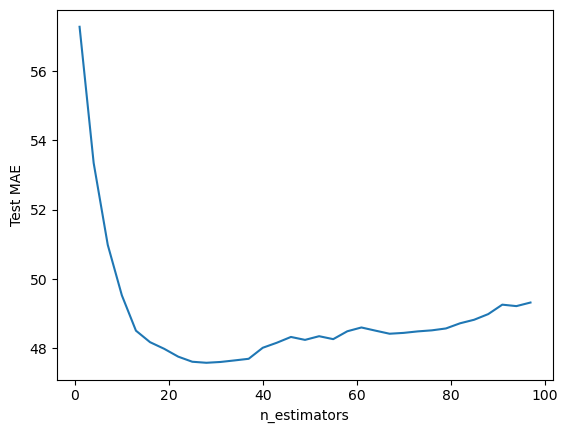

In [32]:
plt.plot(n_estimators_list, test_error)
plt.xlabel('n_estimators')
plt.ylabel('Test MAE')

As you can see, the test error decreases up to about 20–30 estimators and then begins to rise again. This behavior must be familiar to you at this point: overfitting! Let's plot this together with the training error:

In [33]:
n_estimators_list = []
test_error = []
training_error = []
for n_estimators in range(1, 100, 3):
    gbr = GradientBoostingRegressor(random_state=0, n_estimators=n_estimators)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    n_estimators_list.append(n_estimators)
    test_error.append(mae)
    training_error.append(mean_absolute_error(y_train, gbr.predict(X_train)))

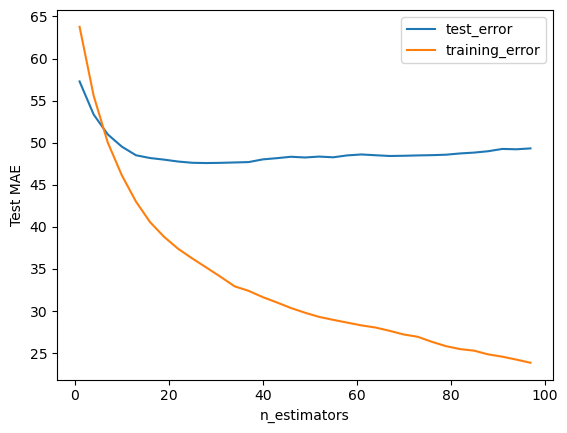

In [34]:
plt.plot(n_estimators_list, test_error, label='test_error')
plt.plot(n_estimators_list, training_error, label='training_error')
plt.xlabel('n_estimators')
plt.ylabel('Test MAE')
plt.legend()

A masterpiece of a plot. We need to understand the hyperparameters next to prevent overfitting.

<mark>YOUR TURN</mark>

Try [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) on the breast cancer dataset:

In [35]:
from sklearn.datasets import load_breast_cancer
# YOUR CODE HERE

## 3. Hyperparameters

Most hyperparameters will look familiar from decision trees and random forests. Gradient boosting adds a few parameters that control how each tree corrects the errors of the ensemble. Different libraries implement these ideas in slightly different ways, so aim to understand their role conceptually rather than tuning them mechanically. We will cover:

- Learning Rate
- Early Stopping
- Loss

### 3.1 Learning Rate

Let's get back to the problem we encountered previously, where adding trees increased the test error in our initial implementation:

In [36]:
n_estimators = 50
boosted_forest = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    # next iteration
    y_pred = dt.predict(X_train)
    y_residual = y_residual - y_pred

y_pred = sum(dt.predict(X_test) for dt in boosted_forest)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 62.70801978845268


The reason this implementation fails is that we have not included a learning rate, so the model updates in large jumps rather than taking the small, controlled steps needed to avoid overshooting the optimum. The key idea is to reduce the influence of each tree by scaling its contribution with a step size. This works exactly like gradient descent and can be implemented as:

```python
y_residual = y_residual - learning_rate * y_pred
```

In [37]:
learning_rate = 0.1 # ADD lr
n_estimators = 50
boosted_forest = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    y_pred = dt.predict(X_train)
    y_residual = y_residual - learning_rate * y_pred # ADD lr
y_pred = sum(learning_rate * dt.predict(X_test) for dt in boosted_forest) # ADD lr
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 48.29746417234982


Suddenly the results are much closer to the scikit-learn implementation 🥳🥳 This shows that the core idea behind boosting is conceptually simple, even if production implementations add many refinements.

In [38]:
# learning rate = 1
# this is equal to our initial non-learning rate implementation
learning_rate = 1
n_estimators = 50
boosted_forest = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    y_pred = dt.predict(X_train)
    y_residual = y_residual - learning_rate * y_pred
y_pred = sum(learning_rate * dt.predict(X_test) for dt in boosted_forest)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 62.70801978845268


Now let's understand the influence of changing the learning rate, by repeating the test error vs `n_estimators` plot at different learning rates:

In [39]:
plot_dict = {}

for learning_rate in [0.01, 0.03, 0.1, 0.3, 1]:

    x_for_plotting = []
    y_for_plotting = []
    for n_estimators in range(1, 100, 3):
        gbr = GradientBoostingRegressor(random_state=0, n_estimators=n_estimators, learning_rate=learning_rate)
        gbr.fit(X_train, y_train)
        y_pred = gbr.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        x_for_plotting.append(n_estimators)
        y_for_plotting.append(mae)

    plot_dict[learning_rate] = (x_for_plotting, y_for_plotting)

Text(0, 0.5, 'Test MAE')

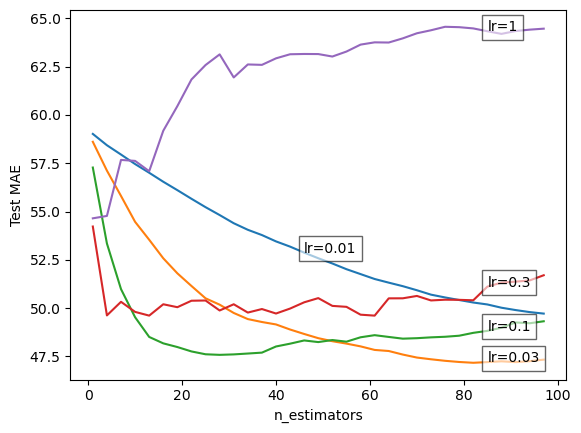

In [40]:
annotation_location = {0.01: 15, 0.03: -5, 0.1: -5, 0.3: -5, 1: -5}
for lr in plot_dict:
    x_vals, y_vals = plot_dict[lr]
    plt.plot(x_vals, y_vals)
    # annotate lr on the curves
    plt.text(x_vals[annotation_location[lr]], y_vals[annotation_location[lr]], f'lr={lr}', fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='black'))
    
plt.xlabel('n_estimators')
plt.ylabel('Test MAE')

The best way to read this plot is to track how the behavior changes as the learning rate decreases from 1 to 0.01.

- For `lr = 1` the error shoots up immediately, which tells us the step size is far too large.
- For `lr = 0.3` the curve improves slightly but still overshoots, so it remains too high.
- For `lr = 0.1` we finally get a smooth trajectory with a clear minimum around 20–30 trees, although the learning rate may still be a bit high.
- For `lr = 0.03` the error decreases more slowly and appears to reach an even lower value than the `lr = 0.1` optimum.
- For `lr = 0.01` the curve looks poor only because we stopped at 100 trees; with more boosting rounds it might reach a better solution.

This illustrates the tradeoff between the learning rate and the number of estimators. Smaller learning rates often lead to better generalization but require more trees and longer training times. These two hyperparameters must be tuned together. Choosing 100 trees for `lr = 0.01` leads to underfitting because the model needs many more steps, whereas choosing 100 trees for `lr = 0.1` leads to overfitting because the steps are too large.

### 3.2 Early Stopping

The key idea to tune `lr` and `n_estimators` together is to use early stopping. Set `n_estimators` to a large value, monitor the validation error after each tree, and stop when the error starts to rise. However, it is not sensible to stop the moment a single tree increases the error. The curve is not perfectly smooth and small temporary increases can occur even when the overall trend is improving. A better approach is to use patience: allow the model to continue for several more iterations, for example 20, and stop only if the error has not improved during that window. This is called early stopping because training ends before reaching the maximum number of estimators. For this reason it is best to set `n_estimators` high and rely on early stopping to find the right point. If training actually reaches `n_estimators` without stopping, the model is likely underfitting, as in the case we have seen above with `lr=0.01` and `n_estimators=100`.

In [41]:
# we need a validation set
# instead of tracking the test error
# you should know why at this point
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=1/10, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=1/9, random_state=0)

In [42]:
# let's repeat what we have done
# only replace the test data with the validation data
learning_rate = 0.1
n_estimators = 100
boosted_forest = []
mae_values = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    y_pred = dt.predict(X_train)
    y_residual = y_residual - learning_rate * y_pred

    y_pred = sum(learning_rate * dt.predict(X_val) for dt in boosted_forest)
    mae = mean_absolute_error(y_val, y_pred)
    mae_values.append(mae)

Text(0.5, 0, 'n_estimators')

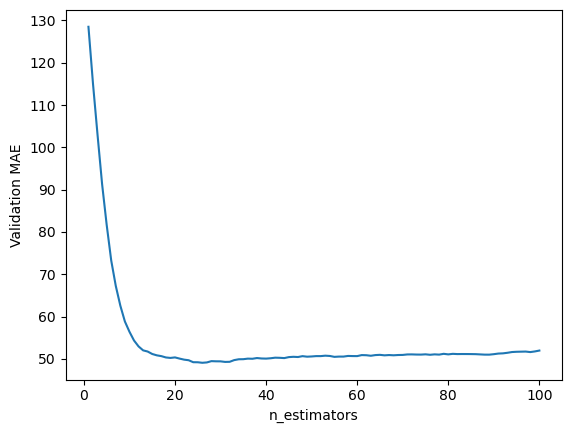

In [43]:
n_estimators_list = list(np.arange(len(mae_values))+1)
plt.plot(n_estimators_list, mae_values)
plt.ylabel('Validation MAE')
plt.xlabel('n_estimators')

In [44]:
# This is where we want to stop
best_val_mae = min(mae_values)
best_n_estimators = n_estimators_list[mae_values.index(best_val_mae)]

print(f"Best validation MAE: {best_val_mae:.2f}")
print(f"Best n_estimators: {best_n_estimators}")

Best validation MAE: 49.06
Best n_estimators: 26


a closer look to the vicinity:

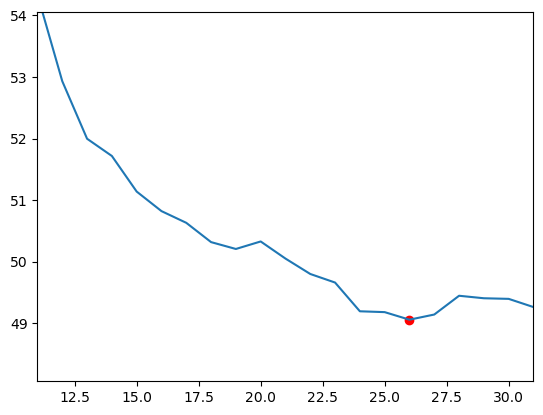

In [45]:
plt.plot(n_estimators_list, mae_values)
plt.xlim(best_n_estimators-15,best_n_estimators+5)
plt.ylim(best_val_mae-1,best_val_mae+5)
plt.scatter(best_n_estimators, best_val_mae, color='red')

here is how we can add early stopping, changes marked by comments:

In [ ]:
learning_rate = 0.1
n_estimators = 500
boosted_forest = []
mae_values = []
y_residual = y_train.copy()

# Addition for early stopping
patience = 20  # num iterations to wait without improvement
best_mae = float("inf") # keep track of the best mae so far
best_iter = -1 # keep track of the best iter so far
no_improve_count = 0 # if this value hits patience we break

for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    y_pred_train = dt.predict(X_train)
    y_residual = y_residual - learning_rate * y_pred_train

    y_pred_val = sum(learning_rate * tree.predict(X_val) for tree in boosted_forest)
    mae = mean_absolute_error(y_val, y_pred_val)
    mae_values.append(mae)

    # Addition for early stopping
    if mae < best_mae:
        best_mae = mae
        best_iter = i
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"Early stopping at iteration {i} with best iteration {best_iter} and MAE={best_mae:.4f}")
            break

Early stopping at iteration 45 with best iteration 25 and MAE=49.0615


Keep in mind that when we use early stopping with patience, we do not actually stop at the minimum. Because we use patience, training continues past the optimum and only stops after the model fails to improve for the amount of rounds equal to patience.

In [47]:
# MAE will be higher
y_pred = sum(learning_rate*dt.predict(X_val) for dt in boosted_forest)
mae = mean_absolute_error(y_val, y_pred)
print("MAE:", mae)

MAE: 50.49875326407133


so we need to slice the forest until the optimum point:

In [48]:
# keep only the trees up to the best iteration
best_n_estimators = best_iter + 1
boosted_forest = boosted_forest[:best_n_estimators] # slice until the optimum
mae_values = mae_values[:best_n_estimators]

print(f"Using {best_n_estimators} trees with best validation MAE = {best_mae:.4f}")

Using 26 trees with best validation MAE = 49.0615


In [49]:
y_pred = sum(learning_rate*dt.predict(X_val) for dt in boosted_forest)
mae = mean_absolute_error(y_val, y_pred)
print("MAE:", mae)

MAE: 49.06145405276121


final step would be to report the test error.

In [50]:
# Test error
y_pred = sum(learning_rate*dt.predict(X_test) for dt in boosted_forest)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 44.98092366920092


### 3.3 Loss

We mentioned above that the foundations of gradient boosting were laid by Jerome Friedman in 2001 in his paper [Greedy Function Approximation: A Gradient Boosting Machine](https://doi.org/10.1214/aos/1013203451). In the abstract he says:

>Function estimation/approximation is viewed from the perspective of numerical optimization in function space, rather than parameter space. A connection is made between stagewise additive expansions and steepest descent minimization. A general gradient descent “boosting” paradigm is developed for additive expansions based on any fitting criterion. Specific algorithms are presented for <mark>least-squares, least absolute deviation, and Huber-M loss functions</mark> for regression, and multiclass logistic likelihood for classification.

You learned gradient descent in the _Mathematical Foundations for Machine Learning_ module. Gradient Descent tries to find the best parameters (a search in the parameter space).

$$new\_parameters = old\_parameters − lr × gradient\_of\_the\_loss\_at\_the\_old\_parameters$$

The analogous rule for gradient boosting (the update in function space) becomes:

$$new\_function = old\_function − lr × tree\_that\_approximates\_the\_gradient\_of\_the\_loss$$

How is loss a hyperparameter in our implementation?


In [ ]:
learning_rate = 0.1
n_estimators = 100
boosted_forest = []
mae_values = []
y_residual = y_train.copy()
for i in range(n_estimators):
    dt = DecisionTreeRegressor(random_state=0, max_depth=max_depth)
    dt.fit(X_train, y_residual)
    boosted_forest.append(dt)
    y_pred = dt.predict(X_train)
    
    # HERE IT IS
    y_residual = y_residual - learning_rate * y_pred # GRADIENT OF THE LOSS

    y_pred = sum(learning_rate * dt.predict(X_val) for dt in boosted_forest)
    mae = mean_absolute_error(y_val, y_pred)
    mae_values.append(mae)

the loss we implemented is the squared error (you are seeing the gradient in the code). In scikit-learn this is the default loss:

In [52]:
gbr = GradientBoostingRegressor(random_state=0, n_estimators=50, loss='squared_error')
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 43.496561548454956


Check the documentation for available loss functions:

>**loss{‘squared_error’, ‘absolute_error’, ‘huber’, ‘quantile’}, default=’squared_error’**

>Loss function to be optimized. ‘squared_error’ refers to the squared error for regression. ‘absolute_error’ refers to the absolute error of regression and is a robust loss function. ‘huber’ is a combination of the two. ‘quantile’ allows quantile regression (use alpha to specify the quantile). See Prediction Intervals for Gradient Boosting Regression for an example that demonstrates quantile regression for creating prediction intervals with loss='quantile'.

In [53]:
gbr = GradientBoostingRegressor(random_state=0, n_estimators=50, loss='huber')
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 44.17534859036145


## 4. Popular gradient boosting frameworks

The most popular gradient boosting frameworks are [XGBoost](https://xgboost.readthedocs.io/en/stable/), [LightGBM](https://lightgbm.readthedocs.io/en/latest/index.html) and [CatBoost](https://catboost.ai/). They provide highly optimized implementations of boosting algorithms designed for speed, accuracy and practical use on large datasets. They follow the same core principles while introducing practical advantages. XGBoost is known for strong regularization and dependable performance across many tasks. LightGBM is recognized for very fast training through its histogram based approach and leaf-wise tree growth. CatBoost excels at handling categorical features without manual encoding. All three offer GPU support that can significantly accelerate training. These capabilities have made them widely used in industry and machine learning competitions, and they remain valuable tools for real world predictive modeling.

To use them, you need to install them into your conda environment. At this point, you should be able to install packages by yourself.

<mark>YOUR TURN</mark>

Install `xgboost`.

You can do this at the terminal or alternatively inside the Jupyter Notebook by using:

```python
!pip install xgboost
```

In [54]:
# YOUR CODE HERE

The default model works very similar to scikit-learn:

In [55]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [56]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 47.32403361002604


and even most hyperparameters follow the scikit-learn convention:

In [57]:
model = XGBRegressor(random_state=0, max_depth=3, learning_rate=0.1, n_estimators=50)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

However, there are differences as well. For an overview, please read the documentation:

https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor

And [here](https://xgboost.readthedocs.io/en/stable/python/examples/index.html) you can see a few different use cases for XGBoost in Python.

Now let's see how early stopping works, at first we can define it as a _callback_.

A callback is simply a small piece of code that you give to another function so that it can be called back at specific moments during its execution. Think of it as: “While you are training the model, also do this extra thing every time you finish a tree or an epoch.”

In [58]:
# rounds is patience
# save_best is what we did to get the best model rather than best+patience
from xgboost.callback import EarlyStopping
early_stopping = EarlyStopping(rounds=50, save_best=True)

the next step is, when we call the model, provide the early_stopping callback as well as any other hyperparameters. Notice how n_estimators is a large value but the training will stop before that:

In [59]:
model = XGBRegressor(
    random_state=0,
    learning_rate=0.1,
    n_estimators=1000,
    eval_metric='mae',
    callbacks=[early_stopping])

In [60]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

[0]	validation_0-mae:66.13076
[1]	validation_0-mae:63.34665
[2]	validation_0-mae:60.79326
[3]	validation_0-mae:59.02360
[4]	validation_0-mae:57.54507
[5]	validation_0-mae:56.33283
[6]	validation_0-mae:55.08610
[7]	validation_0-mae:54.92954
[8]	validation_0-mae:54.63071
[9]	validation_0-mae:54.41662
[10]	validation_0-mae:53.92030
[11]	validation_0-mae:53.56398
[12]	validation_0-mae:53.18500
[13]	validation_0-mae:53.17768
[14]	validation_0-mae:52.84044
[15]	validation_0-mae:52.74953
[16]	validation_0-mae:52.96077
[17]	validation_0-mae:52.96833
[18]	validation_0-mae:52.73616
[19]	validation_0-mae:52.59935
[20]	validation_0-mae:52.63619
[21]	validation_0-mae:52.68559
[22]	validation_0-mae:52.67223
[23]	validation_0-mae:52.51425
[24]	validation_0-mae:52.75643
[25]	validation_0-mae:52.69494
[26]	validation_0-mae:52.85411
[27]	validation_0-mae:52.86028
[28]	validation_0-mae:52.93269
[29]	validation_0-mae:52.93620
[30]	validation_0-mae:53.08301
[31]	validation_0-mae:53.05855
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,[<xgboost.call...t 0x166fd6680>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


XGBoost keeps everything you need for a learning curve inside the trained model.

In [61]:
evals_result = model.evals_result()
evals_result.keys()

dict_keys(['validation_0'])

Text(0.5, 0, 'n_estimators')

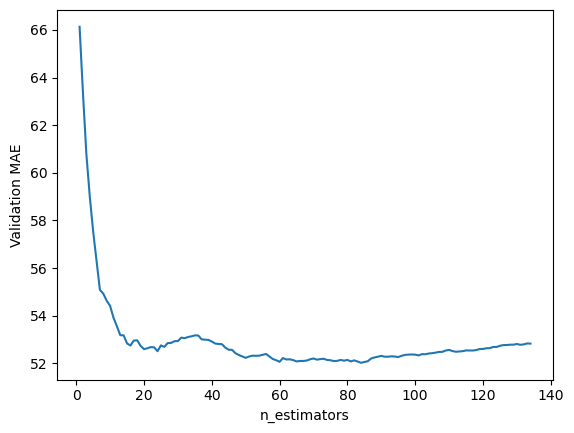

In [62]:
mae_vals = evals_result['validation_0']['mae']
n_estimators_list = list(np.arange(len(mae_vals))+1)
plt.plot(n_estimators_list, mae_vals)
plt.ylabel('Validation MAE')
plt.xlabel('n_estimators')

<mark>YOUR TURN</mark>

Visit the [CatBoost documentation](https://catboost.ai/docs/en/) and follow the instructions to install CatBoost in your environment. Then train a [`CatBoostRegressor`](https://catboost.ai/docs/en/concepts/python-reference_catboostregressor) on the same dataset we have been using in this notebook.


In [63]:
# YOUR CODE HERE